In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from src.data import *
from src.post_process_functions import *
from src.data_format import format_output, LIST_COLS

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /Users/lseverino/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lseverino/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
# load metadata
metadata = pd.read_csv(DATA_LABELLED / "metadata_all_reports_220626.csv")

In [3]:
# inspect metadata for labelled reports
appeal_codes = [
    "MDRDZ011",
    "MDRPK026",
    "MDRCM039",
    "MDRBJ019",
    "MDRSD034",
    "MDRNG041",
    "MDRRW022",
    "MDRZM022",
    "MDRUG050",
    "MDRMZ024",
    "MDRIR009",
    "MDRTP004",
    "MDRVU012",
    "MDRDZ007",
    "MDRAF014",
    "MDRCM036",
    "MDRDZ008",
    "MDRPH036",
    "MDRHT018",
    "MDRID013",
    "MDR55001",
    "MDRJO003",
    "MDRLB013",
    "MDRPK018",
    "MDRTJ035",
    "MDRCN006",
    "MDRBD022",
    "MDRYE011",
    "MDRS2001",
    "MDRIQ014",
    "MDRGN015",
    "MDRSV012",
    "MDRMY003",
    "MDRBD015",
    "MDRKE058",
    "MDRCO023",
    "MDRGW003",
    "MDRHU005",
    "MDRPH021",
    "MDRRS015",
    "MDRMN017",
    "MDRGT009",
    "MDRPG008",
    "MDREC019",
    "MDRTN010",
    "MDRCR012",
    "MDRGE019",
    "MDRKZ010",
    "MDRUY004",
]

In [4]:
# or only look at the appeals that were actually labelled
labelled_df = pd.read_csv(
    DATA_LABELLED / f"labelled_reports_all_v24062026.csv"
)
labelled_appeals = labelled_df.appealCode.unique().tolist()

In [5]:
metadata

,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,uid
0,MDRBI016do.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,-,DREF Operation,2019-12-30T00:00:00+01:00,30/12/2019,Burundi,MDRBI016,DREF Operation,2798360b628f938c1b9e279dee0588dc
1,MDRAL008ou1.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Earthquake,Operations Update,2019-12-30T00:00:00+01:00,30/12/2019,Albania,MDRAL008,Operations Update,16e2e057285c77894eddd1dab9decac4
2,MDRPH038ea.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Typhoon,Emergency Appeal,2019-12-29T00:00:00+01:00,29/12/2019,Philippines,MDRPH038,-,3ac96244b3e3a53c940cfab03c4ecb8e
3,MDRLK010do.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,-,DREF Operation,2019-12-27T00:00:00+01:00,27/12/2019,Sri Lanka,MDRLK010,DREF Operation,67ea4b07d0a98cccefe1f221176a157d
4,MDRPH038 EPOA.pdf,https://adore.ifrc.org/Download.aspx?FileId=28...,Typhoon,DREF Operation,2019-12-27T00:00:00+01:00,27/12/2019,Philippines,MDRPH038,DREF Operation,8e9687b2aa7c209025a8d6677919a9e6
...,...,...,...,...,...,...,...,...,...,...
18629,MDRSD013fr.pdf,/docs?file=Appeals/12/MDRSD013fr.pdf,Food Insecurity,Final Report,2014-01-08T16:01:00+01:00,08/01/2014,Sudan,MDRSD013,Final Report,338df2d51fb32ca856190f78fea1c510
18630,MDRSD017dfr.pdf,/docs?file=Appeals/13/MDRSD017dfr.pdf,Population Movement,DREF Operation Final Report,2014-01-07T11:05:00+01:00,07/01/2014,Sudan,MDRSD017,DREF Operation Final Report,19a6f55adaf7f326afb6e3b5b1fbab41
18631,MDRSV006do.pdf,https://adore.ifrc.org/Download.aspx?FileId=53513,-,DREF Operation,2014-01-06T00:00:00+01:00,06/01/2014,El Salvador,MDRSV006,DREF Operation,f5e278f71b22046c595440b330671744
18632,MDRVC002do.pdf,https://adore.ifrc.org/Download.aspx?FileId=53512,-,DREF Operation,2014-01-03T00:00:00+01:00,03/01/2014,St Vincent and Grenadines,MDRVC002,DREF Operation,3e1e610e5af13be644caabe37401b466


In [6]:
labelled_metadata = metadata[metadata["appealCode"].isin(labelled_appeals)]

In [7]:
print(f"Number of appeal codes: {len(labelled_appeals)} ")
print(f"Number of labelled reports: {len(labelled_metadata)} ")

Number of appeal codes: 34 
Number of labelled reports: 186 


In [8]:
missing_appeal_codes = set(labelled_appeals) - set(labelled_metadata["appealCode"])
print(f"Missing appeal codes: {missing_appeal_codes}")

Missing appeal codes: set()


In [9]:
# order dataframe by appeal codes
rank = {v: i for i, v in enumerate(labelled_appeals)}
labelled_reports = labelled_metadata.sort_values(
    by="appealCode", key=lambda s: s.map(rank)
)

In [10]:
labelled_reports

,reportName,reportLink,disasterType,origType,dateTime,date,location,appealCode,appealType,uid
4788,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83724...,Cold Wave,MDRLB013fr,2023-10-03T00:00:00+02:00,03/10/2023,Lebanon,MDRLB013,DREF Operation Final Report,0df9cdba1a17753763c64fb4b04aec0e
5141,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83723...,Cold Wave,MDRLB013do,2023-02-24T00:00:00+01:00,24/02/2023,Lebanon,MDRLB013,DREF Operation,e94f9ffb43c1fd46e428f295aecee3b8
3779,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89728...,Earthquake,MDRVU012_EA,2024-12-20T00:00:00+01:00,20/12/2024,Vanuatu,MDRVU012,Emergency Appeal,34856d66267fb9aca19d0268be976273
3741,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89801...,Earthquake,MDRVU012OS,2025-01-12T00:00:00+01:00,12/01/2025,Vanuatu,MDRVU012,Operational strategy,354698614fdb2690394bf49eee57ce3f
3689,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89890...,Earthquake,MDRVU012OU1,2025-02-05T00:00:00+01:00,05/02/2025,Vanuatu,MDRVU012,Operations Update,cf05105a27ff4679e1f9452593198dc5
...,...,...,...,...,...,...,...,...,...,...
1577,MDRDZ008do.pdf,https://adore.ifrc.org/Download.aspx?FileId=57...,DREF,DREF Operation,2022-09-05T00:00:00+02:00,05/09/2022,Algeria,MDRDZ008,DREF Operation,272abf1f598ee2578113a0a32e0e4b64
4733,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/R6794...,Fire,MDRDZ008fr,2023-11-10T00:00:00+01:00,10/11/2023,Algeria,MDRDZ008,DREF Operation Final Report,f4140d693d286cfff1c1ee4affbc1a4d
5086,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/84021...,Fire,MDRDZ008DU,2023-03-28T00:00:00+02:00,28/03/2023,Algeria,MDRDZ008,DREF Operation Update,d4a5cef104d7fcc38a92114fd6d19bb4
4214,Cameroon - Landslide (MDRCM036),https://go-api.ifrc.org/api/DownloadFile/85569...,Landslide,MDRCM036dfr,2024-07-04T00:00:00+02:00,04/07/2024,Cameroon,MDRCM036,DREF Operation Final Report,b741be78f799f56ced981e49ef766a02


In [11]:
years_meta = labelled_reports.dateTime.apply(lambda x: pd.to_datetime(x).year).value_counts()
years_labelled = labelled_df.groupby("appealCode").head(1).reportDate.apply(lambda x: pd.to_datetime(x).year).value_counts()

In [12]:
years_meta

dateTime
2024    44
2023    28
2019    28
2025    26
2018    21
2020    17
2021    10
2022     9
2017     3
Name: count, dtype: int64

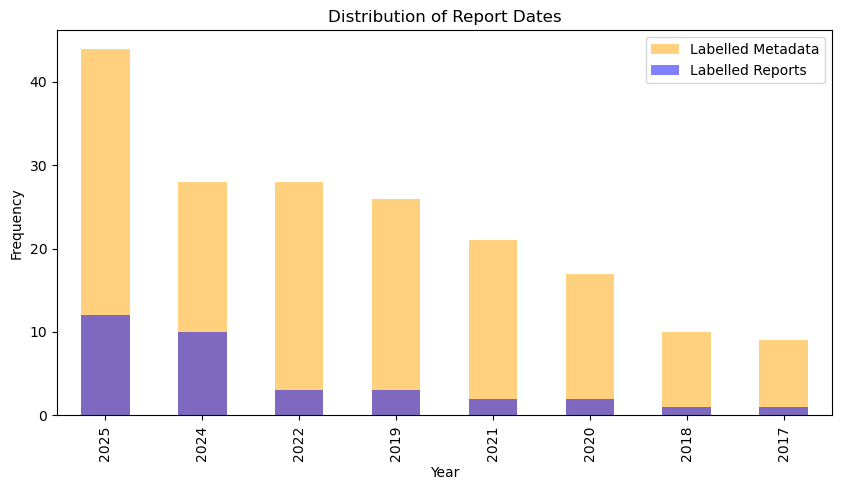

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
#ax.hist(years_meta, bins=20, alpha=0.5, label="Labelled Metadata")
#ax.hist(years_labelled, bins=20, alpha=0.5, label="Labelled Reports")
years_meta.plot(kind="bar", alpha=0.5, label="Labelled Metadata", ax=ax, color="orange")
years_labelled.plot(kind="bar", alpha=0.5, label="Labelled Reports", ax=ax, color="blue")
ax.set_xlabel("Year")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Report Dates")
ax.legend()

In [16]:
labelled_metadata["dateTime"] = pd.to_datetime(
    labelled_metadata["date"], format="%d/%m/%Y", errors="coerce"
)
labelled_df["dateTime"] = pd.to_datetime(labelled_df["reportDate"], format="%Y-%m-%d", errors="coerce")
#labelled_df["dateTime"] = pd.to_datetime(labelled_df["reportDate"]).dt.normalize()

#labelled_metadata["dateTime"] = (
#    pd.to_datetime(labelled_metadata["dateTime"], dayfirst=True, utc=True)
#    .dt.tz_convert(None)
#    .dt.normalize()
#)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_29946/510329605.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled_metadata["dateTime"] = pd.to_datetime(


In [46]:
# merge two dataframes to see if there are any differences in the metadata and the labelled reports
labelled_df_one_row = labelled_df.groupby("appealCode").head(1)
merged_metadata_both = pd.merge(
    labelled_df_one_row,
    labelled_metadata,
    left_on=["appealCode", "dateTime"],
    right_on=["appealCode", "dateTime"],
    how="inner",
)

In [56]:
merged_metadata_both

,reportDate,impactSubtype,impactValue,impactUnit,impactValuePrecision,impactValueMin,impactValueMax,annotation,country,location_x,...,reportDate_orig,dateTime,reportName,reportLink,disasterType,origType,date,location_y,appealType,uid
0,2022-04-01,DREF Allocation & Funding requirements,497168.0,CHF,exact,NaN,NaN,['DREF Final Report Kazakhstan: Drought DREF o...,['Kazakhstan'],"['Kyzylorda', 'Mangystau', 'Turkestan']",...,2022-04-01,2022-04-01,MDRKZ010dfr.pdf,https://adore.ifrc.org/Download.aspx?FileId=51...,Drought,DREF Operation Final Report,01/04/2022,Kazakhstan,-,d4f0a8e060c97b0e72e69a5f25489096
1,2021-09-20,Affected People,170000.0,people,approx,NaN,NaN,['Operation Update Indonesia: Sulawesi Earthqu...,['Indonesia'],NaN,...,2021-09-20,2021-09-20,MDRID013eu29.pdf,https://adore.ifrc.org/Download.aspx?FileId=44...,Earthquake,Operations Update,20/09/2021,Indonesia,Operations Update,9045dd9f41d3fb3cc8adb5e874462934
2,2022-04-12,DREF Allocation & Funding requirements,167716.0,CHF,exact,NaN,NaN,['Emergency Plan of Action (EPoA) Ecuador: Ear...,['Ecuador'],"['Cotopaxi', 'Esmeraldas', 'Guayas', 'Imbabura...",...,2022-04-12,2022-04-12,MDREC019do.pdf,https://adore.ifrc.org/Download.aspx?FileId=51...,Earthquake,DREF Operation,12/04/2022,Ecuador,DREF Operation,d15db9307397886055ad107497bfec14
3,2020-11-30,DREF Allocation & Funding requirements,315292.0,CHF,exact,NaN,NaN,['Final Report Pakistan: Severe winter DREF op...,['Pakistan'],"['Balochistan', 'Azad Jammu and Kashmir']",...,2020-11-30,2020-11-30,MDRPK018dfr.pdf,https://adore.ifrc.org/Download.aspx?FileId=36...,Cold Wave,DREF Operation Final Report,30/11/2020,Pakistan,-,af2195a5006a91ec296399ccbb5f54a7
4,2018-11-24,DREF Allocation & Funding requirements,209398.0,CHF,exact,NaN,NaN,['EEmmeerrggeennccyy PPllaann ooff AAccttiioon...,['Papua New Guinea'],NaN,...,2018-11-24,2018-11-24,MDRPG008dfr.pdf,https://adore.ifrc.org/Download.aspx?FileId=21...,Earthquake,DREF Operation Final Report,24/11/2018,Papua New Guinea,-,a1d3c99f697b3d7c92e6d4324e42b0fb
5,2022-08-03,Affected People,76790.0,people,approx,NaN,NaN,"[""P a g e 1 Internal DREF Operation n MDRYE011...",['Yemen'],"['Marib', 'Al Mahwit', 'Taiz', 'Ibb', 'Hadrama...",...,2022-08-03,2022-08-03,MDRYE011do.pdf,https://adore.ifrc.org/Download.aspx?FileId=55...,-,DREF Operation,03/08/2022,Yemen,DREF Operation,808620a82c71fc7362c4dfa4c195c0da
6,2021-12-27,Affected People,7500.0,people,approx,7500.0,NaN,['P a g e 1 Internal DREF Operation n MDRIQ014...,['Iraq'],"['Erbil', 'Kirkuk']",...,2021-12-27,2021-12-27,MDRIQ014do.pdf,https://adore.ifrc.org/Download.aspx?FileId=48...,DREF,DREF Operation,27/12/2021,Iraq,DREF Operation,f0ae50a3ab0431521b797b48537021d6
7,2024-04-26,Other Economic & Livelihood impact,NaN,NaN,NaN,NaN,NaN,['The above-average rainfall during this March...,['Kenya'],"['Lake Victoria Basin', 'Highlands West of the...",...,2024-04-26,2024-04-26,Kenya - Floods (MDRKE058),https://go-api.ifrc.org/api/DownloadFile/87656...,Flood,MDRKE058eu3,26/04/2024,Kenya,Operations Update,13c2e740113a2c3b3bf559a4ad24562b
8,2024-09-06,Displaced People,NaN,NaN,approx,NaN,NaN,"['From August 8 to August 13, 2024, continuous...",['Nigeria'],"['Bauchi', 'Sokoto', 'Zamfara']",...,2024-09-06,2024-09-06,Nigeria - Floods (MDRNG041),https://go-api.ifrc.org/api/DownloadFile/88650...,Flood,MDRNG041do,06/09/2024,Nigeria,DREF Operation,5354e546a5da3f27c7c777f16d02e429
9,2024-08-30,Affected People,69283.0,people,exact,NaN,NaN,['Appeal MDRUG050 Total DREF Allocation CHF 47...,['Uganda'],[],...,2024-08-30,2024-08-30,Uganda - Floods (MDRUG050),https://go-api.ifrc.org/api/DownloadFile/88608...,Flood,MDRUG050du1,30/08/2024,Uganda,DREF Operation Update,ebffb54b27e731e7b5e391d1b20a2246


In [57]:
merged_metadata_both[
    ["appealCode", "dateTime", "reportName", "disasterType","origType", "reportLink"]
]

,appealCode,dateTime,reportName,disasterType,origType,reportLink
0,MDRKZ010,2022-04-01,MDRKZ010dfr.pdf,Drought,DREF Operation Final Report,https://adore.ifrc.org/Download.aspx?FileId=51...
1,MDRID013,2021-09-20,MDRID013eu29.pdf,Earthquake,Operations Update,https://adore.ifrc.org/Download.aspx?FileId=44...
2,MDREC019,2022-04-12,MDREC019do.pdf,Earthquake,DREF Operation,https://adore.ifrc.org/Download.aspx?FileId=51...
3,MDRPK018,2020-11-30,MDRPK018dfr.pdf,Cold Wave,DREF Operation Final Report,https://adore.ifrc.org/Download.aspx?FileId=36...
4,MDRPG008,2018-11-24,MDRPG008dfr.pdf,Earthquake,DREF Operation Final Report,https://adore.ifrc.org/Download.aspx?FileId=21...
5,MDRYE011,2022-08-03,MDRYE011do.pdf,-,DREF Operation,https://adore.ifrc.org/Download.aspx?FileId=55...
6,MDRIQ014,2021-12-27,MDRIQ014do.pdf,DREF,DREF Operation,https://adore.ifrc.org/Download.aspx?FileId=48...
7,MDRKE058,2024-04-26,Kenya - Floods (MDRKE058),Flood,MDRKE058eu3,https://go-api.ifrc.org/api/DownloadFile/87656...
8,MDRNG041,2024-09-06,Nigeria - Floods (MDRNG041),Flood,MDRNG041do,https://go-api.ifrc.org/api/DownloadFile/88650...
9,MDRUG050,2024-08-30,Uganda - Floods (MDRUG050),Flood,MDRUG050du1,https://go-api.ifrc.org/api/DownloadFile/88608...


In [47]:
# check diverging date between data that was not matched
appeal_no_match = list(set(labelled_appeals) - set(merged_metadata_both["appealCode"]))

In [48]:
merged_metadata_appeal = pd.merge(
    labelled_df_one_row,
    labelled_metadata,
    left_on=["appealCode"],
    right_on=["appealCode"],
    how="inner",
)

In [49]:
missing_data = merged_metadata_appeal[merged_metadata_appeal.appealCode.isin(appeal_no_match)].dropna(how="all")

In [51]:
missing_data[["appealCode", "dateTime_x", "dateTime_y", "reportName", "reportLink"]]

,appealCode,dateTime_x,dateTime_y,reportName,reportLink
0,MDRLB013,2025-12-08,2023-10-03,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83724...
1,MDRLB013,2025-12-08,2023-02-24,Lebanon - Severe Weather (MDRLB013),https://go-api.ifrc.org/api/DownloadFile/83723...
2,MDRVU012,2025-10-12,2025-12-10,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/93925...
3,MDRVU012,2025-10-12,2025-08-28,MDRVU012OU3.pdf,https://go-api.ifrc.org/api/DownloadFile/89892...
4,MDRVU012,2025-10-12,2025-02-27,Vanuatu - Earthquake (MDRVU012),https://go-api.ifrc.org/api/DownloadFile/89891...
...,...,...,...,...,...
181,MDRDZ008,2025-12-08,2022-09-05,MDRDZ008do.pdf,https://adore.ifrc.org/Download.aspx?FileId=57...
182,MDRDZ008,2025-12-08,2023-11-10,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/R6794...
183,MDRDZ008,2025-12-08,2023-03-28,Algeria - Forest Wildfires (MDRDZ008),https://go-api.ifrc.org/api/DownloadFile/84021...
184,MDRCM036,2025-12-08,2024-07-04,Cameroon - Landslide (MDRCM036),https://go-api.ifrc.org/api/DownloadFile/85569...


In [60]:
appeal_no_match

['MDRJO003',
 'MDRS2001',
 'MDRCM036',
 'MDRMN017',
 'MDRTJ035',
 'MDRLB013',
 'MDRDZ008',
 'MDRVU012',
 'MDRBD022',
 'MDRSV012',
 'MDRRS015',
 'MDRIR009',
 'MDRUY004',
 'MDRZM022',
 'MDRMY003',
 'MDRCN006']